# WILDCARD v6.9.10 Strategy & Revenue Sensitivity

## tl;dr

The generated summary below is shown only after the notebook validates both artifacts, their source/script SHA-256 lineage, all 2,800 raw strategy outcomes, paired seeds, stored aggregates, and the 12 revenue calculations.

In [1]:
from pathlib import Path
import hashlib, json, math, statistics
from collections import Counter
from IPython.display import Markdown, SVG, display

VERSION, N_STRATEGIES, N_RUNS = "6.9.10", 7, 400
DAU_LEVELS = [50, 200, 1000, 10000]

def root_dir():
    for path in [Path.cwd(), *Path.cwd().parents]:
        if (path/"www/index.html").exists() and (path/"docs/release").exists():
            return path.resolve()
    raise FileNotFoundError("WILDCARD repository root not found")

def sha(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

def table(headers, rows):
    clean=lambda x:str(x).replace("|","\\|").replace("\n"," ")
    return "\n".join([
        "| "+" | ".join(map(clean,headers))+" |",
        "| "+" | ".join("---" for _ in headers)+" |",
        *["| "+" | ".join(map(clean,row))+" |" for row in rows]
    ])

def money(value):
    return math.floor(value*100+0.5)/100

root=root_dir()
strategy_path=root/"docs/release/wildcard-v6.9.10-strategy-results.json"
revenue_path=root/"docs/release/wildcard-v6.9.10-revenue-sensitivity.json"
strategy=json.loads(strategy_path.read_text(encoding="utf-8"))
revenue=json.loads(revenue_path.read_text(encoding="utf-8"))
strategies=strategy["strategies"]
checks=[]

def check(name, ok, evidence):
    checks.append((name,bool(ok),evidence))

source_path=root/strategy["source"]
strategy_script=root/strategy["script"]
revenue_script=root/revenue["script"]
source_hash, strategy_script_hash, revenue_script_hash=map(
    sha,(source_path,strategy_script,revenue_script)
)
check("Version",strategy["version"]==revenue["version"]==VERSION,VERSION)
check("Mode",strategy["mode"]=="strategy",strategy["mode"])
check("7 × 400 run declaration",strategy["counts"]=={
    "jokers":57,"strategies":7,"runsPerStrategy":400,"fullRuns":2800
},str(strategy["counts"]))
check("No simulator failures",all(not strategy.get(k,[]) for k in
    ("dataFailures","hookErrors","invariantFailures")),"all three arrays empty")
check("Game-source provenance",source_hash.lower()==strategy["sourceSha256"].lower()==revenue["sourceSha256"].lower(),source_hash)
check("Strategy-script provenance",strategy_script_hash.lower()==strategy["scriptSha256"].lower(),strategy_script_hash)
check("Revenue-script provenance",revenue_script_hash.lower()==revenue["scriptSha256"].lower(),revenue_script_hash)

ids=[s["id"] for s in strategies]
check("Seven unique strategies",len(ids)==len(set(ids))==N_STRATEGIES,", ".join(ids))
seed_rows=[]
aggregate_errors=[]
for s in strategies:
    outcomes=s["outcomes"]
    seeds=[o["seed"] for o in outcomes]
    seed_rows.append(tuple(seeds))
    wins=sum(bool(o["won"]) for o in outcomes)
    h9=sum(o["cleared"]>=8 for o in outcomes)
    h11=sum(o["cleared"]>=10 for o in outcomes)
    expected=(len(outcomes),wins,round(100*wins/N_RUNS,2),round(100*h9/N_RUNS,2),round(100*h11/N_RUNS,2))
    actual=(s["runs"],s["wins"],s["winRate"],s["reachH9"],s["reachH11"])
    if expected!=actual or len(seeds)!=len(set(seeds)) or len(outcomes)!=N_RUNS:
        aggregate_errors.append(s["id"])
check("Raw outcomes reconcile",not aggregate_errors,"400 unique outcomes per strategy; aggregates recomputed")
check("Common paired seeds",len(set(seed_rows))==1 and len(seed_rows[0])==N_RUNS,"same ordered 400 seeds")

ranked=sorted(strategies,key=lambda s:(s["winRate"],s["avgCleared"],s["id"]),reverse=True)
leader, runner_up=ranked[:2]
paired=strategy["pairedAgainstBest"]
check("Paired 2×2 tables",len(paired)==N_STRATEGIES and all(
    r["bestId"]==leader["id"] and sum(r[k] for k in ("bestOnly","strategyOnly","bothWin","bothLose"))==N_RUNS
    for r in paired
),f"leader={leader['id']}")

config=revenue["currentConfiguration"]
check("Current ads are non-production",config["demoAdMobIds"] and config["adTesting"] and
      config["currentProductionAdRevenueGbp"]==0,"demo IDs; test mode; £0")
check("Play activation unverified",config["playConsoleProductActivationVerified"] is False,"repository cannot prove console state")

scenarios={s["id"]:s for s in revenue["scenarios"]}
projections={(p["scenario"],p["dau"]):p for p in revenue["projections"]}
expected_keys={(s,d) for s in ("low","base","high") for d in DAU_LEVELS}
check("Revenue grid",set(projections)==expected_keys and revenue["dauLevels"]==DAU_LEVELS,"3 scenarios × 4 DAU levels")

revenue_errors=[]
for (scenario_id,dau),p in projections.items():
    s=scenarios[scenario_id]
    rewarded=dau*s["rewardedViewsPerDauDay"]*s["fillRate"]*s["rewardedEcpmGbp"]/1000
    interstitial=dau*s["interstitialViewsPerDauDay"]*s["fillRate"]*s["interstitialEcpmGbp"]/1000
    ads=30*(rewarded+interstitial)
    mau=dau*s["mauPerDau"]
    payers=mau*s["monthlyPayerRate"]
    gross=payers*s["grossMonthlyArppuGbp"]
    net=gross*(1-s["playFeeRate"])
    expected={
      "estimatedMau":money(mau),"monthlyPayers":money(payers),
      "monthlyRewardedAdsGbp":money(30*rewarded),
      "monthlyInterstitialAdsGbp":money(30*interstitial),
      "monthlyAdsGbp":money(ads),"grossMonthlyIapGbp":money(gross),
      "monthlyIapAfterPlayFeeGbp":money(net),
      "monthlyTotalBeforeTaxRefundsGbp":money(ads+net),
      "monthlyRevenuePerDauGbp":money((ads+net)/dau)
    }
    revenue_errors += [f"{scenario_id}/{dau}/{k}" for k,v in expected.items() if p[k]!=v]
check("Revenue arithmetic",not revenue_errors,"12 rows independently recomputed")

failures=[row for row in checks if not row[1]]
if failures:
    display(Markdown(table(["Failed check","Evidence"],[(n,e) for n,_,e in failures])))
    raise AssertionError(f"{len(failures)} validation checks failed")

def paired_gap(a,b):
    a_by={o["seed"]:int(o["won"]) for o in a["outcomes"]}
    b_by={o["seed"]:int(o["won"]) for o in b["outcomes"]}
    diffs=[a_by[k]-b_by[k] for k in sorted(a_by)]
    mean=statistics.mean(diffs)
    se=statistics.stdev(diffs)/math.sqrt(len(diffs))
    return 100*mean,100*(mean-1.96*se),100*(mean+1.96*se)

gap,gap_low,gap_high=paired_gap(leader,runner_up)
display(Markdown(
 f"**Validation gate: PASS — {len(checks)} checks.**\n\n"
 f"- **Strategy:** {leader['name']} led at **{leader['winRate']:.2f}%** Heat 12 clears "
 f"(Wilson 95% CI {leader['winRate95']['low']:.2f}%–{leader['winRate95']['high']:.2f}%). "
 f"{runner_up['name']} reached {runner_up['winRate']:.2f}%; paired gap "
 f"{gap:.2f} pp (approx. 95% CI {gap_low:.2f} to {gap_high:.2f}).\n"
 f"- **Completeness:** all {N_STRATEGIES*N_RUNS:,} raw runs and common paired seeds reconciled.\n"
 f"- **Revenue:** this is a **sensitivity, not a forecast**. Current demo/test ads earn **£0 production ad revenue**.\n"
 f"- **Sensitivity range:** £{projections[('low',50)]['monthlyTotalBeforeTaxRefundsGbp']:,.2f}–"
 f"£{projections[('high',50)]['monthlyTotalBeforeTaxRefundsGbp']:,.2f}/month at 50 DAU and "
 f"£{projections[('low',10000)]['monthlyTotalBeforeTaxRefundsGbp']:,.2f}–"
 f"£{projections[('high',10000)]['monthlyTotalBeforeTaxRefundsGbp']:,.2f}/month at 10,000 DAU, "
 f"before tax/refunds/chargebacks/FX."
))

**Validation gate: PASS — 15 checks.**

- **Strategy:** Flush engine led at **36.50%** Heat 12 clears (Wilson 95% CI 31.93%–41.33%). Adaptive greedy reached 29.25%; paired gap 7.25 pp (approx. 95% CI 1.14 to 13.36).
- **Completeness:** all 2,800 raw runs and common paired seeds reconciled.
- **Revenue:** this is a **sensitivity, not a forecast**. Current demo/test ads earn **£0 production ad revenue**.
- **Sensitivity range:** £8.79–£111.19/month at 50 DAU and £1,757.25–£22,237.50/month at 10,000 DAU, before tax/refunds/chargebacks/FX.

## Context & Methods

The gameplay unit is one standard run through Heat 12. Seven explicit bot heuristics each receive the same 400 top-level seeds. Deterministic modifier, deck/draw, and shop phase streams improve paired comparability, although paths can diverge after different decisions.

Stored individual intervals are Wilson 95% binomial intervals. The leader comparisons below use an approximate 95% interval for the mean paired per-seed win difference.

### Key Assumptions

- Bots are deterministic heuristics, not observed players or optimized policies.
- Reach H9 means at least eight Heats cleared; reach H11 means at least ten.
- Results apply only to the validated source and simulator hashes.
- Revenue uses assumed fill, views, eCPM, MAU/DAU, payer rate, ARPPU, and Play fee.
- Revenue excludes tax/VAT, refunds, chargebacks, and FX.
- Source product declarations do not prove Play Console activation or live pricing.

## Data

The tables below preserve provenance, completeness, and strategy definitions. Artifact timestamps are UTC.

In [2]:
provenance=[
 ("Game source",strategy["source"],strategy["sourceSha256"],"matched"),
 ("Strategy script",strategy["script"],strategy["scriptSha256"],"matched"),
 ("Strategy results",str(strategy_path.relative_to(root)).replace("\\","/"),sha(strategy_path),strategy["generatedAt"]),
 ("Revenue script",revenue["script"],revenue["scriptSha256"],"matched"),
 ("Revenue results",str(revenue_path.relative_to(root)).replace("\\","/"),sha(revenue_path),revenue["generatedAt"])
]
display(Markdown(table(["Artifact","Path","SHA-256","Status / UTC"],provenance)))
display(Markdown(table(["Check","Status","Evidence"],[(n,"PASS" if ok else "FAIL",e) for n,ok,e in checks])))
display(Markdown(table(
 ["Strategy","Description","Reserve","Preferred IDs","Raw rows"],
 [(s["name"],s["description"],s.get("reserve",0),len(s.get("preferenceIds",[])),len(s["outcomes"])) for s in strategies]
)))

| Artifact | Path | SHA-256 | Status / UTC |
| --- | --- | --- | --- |
| Game source | www/index.html | 116d1878b733667b2fdb87c28e9ed38b5f8010288894e11bbebe9cf9a4c81521 | matched |
| Strategy script | tools/deep-sim-v57.js | 11660571a5ad227b24ff2f205969dba7801df1d79156bdbb64d65078f72ceb09 | matched |
| Strategy results | docs/release/wildcard-v6.9.10-strategy-results.json | 4514103faddd98bf1cb6a8a5111b341867f4be3d01fbe53eb95499c182339e91 | 2026-07-17T00:05:31.993Z |
| Revenue script | tools/revenue-model-v6910.js | 121e632aeadacd3707a75d4821cab9d37a3af609dd6b6bc26b2af50395c269aa | matched |
| Revenue results | docs/release/wildcard-v6.9.10-revenue-sensitivity.json | 52b52ed3fcbafc9e9dc438dc6ff1f4cbf4c90231eba1ddf9a3e4b1e3a3676934 | 2026-07-17T00:25:19.451Z |

| Check | Status | Evidence |
| --- | --- | --- |
| Version | PASS | 6.9.10 |
| Mode | PASS | strategy |
| 7 × 400 run declaration | PASS | {'jokers': 57, 'strategies': 7, 'runsPerStrategy': 400, 'fullRuns': 2800} |
| No simulator failures | PASS | all three arrays empty |
| Game-source provenance | PASS | 116d1878b733667b2fdb87c28e9ed38b5f8010288894e11bbebe9cf9a4c81521 |
| Strategy-script provenance | PASS | 11660571a5ad227b24ff2f205969dba7801df1d79156bdbb64d65078f72ceb09 |
| Revenue-script provenance | PASS | 121e632aeadacd3707a75d4821cab9d37a3af609dd6b6bc26b2af50395c269aa |
| Seven unique strategies | PASS | adaptive_greedy, cheat_synergy, pair_rank, utility_niche, flush_engine, economy_hoarding, xmult_stacking |
| Raw outcomes reconcile | PASS | 400 unique outcomes per strategy; aggregates recomputed |
| Common paired seeds | PASS | same ordered 400 seeds |
| Paired 2×2 tables | PASS | leader=flush_engine |
| Current ads are non-production | PASS | demo IDs; test mode; £0 |
| Play activation unverified | PASS | repository cannot prove console state |
| Revenue grid | PASS | 3 scenarios × 4 DAU levels |
| Revenue arithmetic | PASS | 12 rows independently recomputed |

| Strategy | Description | Reserve | Preferred IDs | Raw rows |
| --- | --- | --- | --- | --- |
| Adaptive greedy | Ranks every offer by broad immediate and scaling value without forcing an archetype. | 0 | 0 | 400 |
| Cheat + hand synergy | Prioritises The Cheat, hand-specific multipliers, hand Boost scaling and flexible hand enablers. | 0 | 9 | 400 |
| Pair and rank boosting | Prioritises rank modifiers and Pair-or-better support. | 0 | 12 | 400 |
| Utility and niche | Prioritises unusual deck, hand-size and conditional utility effects. | 0 | 11 | 400 |
| Flush engine | Prioritises suit, colour and Flush enablers and payoffs. | 0 | 8 | 400 |
| Economy hoarding | Prioritises coin engines and keeps a 25-coin reserve instead of spending for tempo. | 25 | 4 | 400 |
| xMult stacking | Prioritises Jokers with multiplicative scoring hooks, even when the flat base is weak. | 0 | 19 | 400 |

## Results

Completion rates are simulator outcomes, not predicted human win rates. Joker frequency is descriptive co-occurrence and does not estimate causal lift.

### Strategy ranking

| Strategy | Heat 12 | Win rate (Wilson 95% CI) | Reach H9 | Reach H11 | Avg cleared |
| --- | --- | --- | --- | --- | --- |
| Flush engine | 146/400 | 36.50% (31.93–41.33%) | 96.50% | 85.50% | 10.87 |
| Adaptive greedy | 117/400 | 29.25% (25.01–33.89%) | 90.50% | 68.00% | 10.17 |
| Utility and niche | 82/400 | 20.50% (16.83–24.73%) | 85.75% | 59.25% | 9.73 |
| Economy hoarding | 82/400 | 20.50% (16.83–24.73%) | 76.50% | 57.75% | 9.48 |
| Cheat + hand synergy | 46/400 | 11.50% (8.73–15.00%) | 78.00% | 48.50% | 9.14 |
| Pair and rank boosting | 32/400 | 8.00% (5.72–11.08%) | 83.75% | 45.50% | 9.20 |
| xMult stacking | 10/400 | 2.50% (1.36–4.54%) | 83.75% | 50.00% | 9.27 |

### Flush engine Heat-by-Heat clear curve

| Heat cleared | Runs | Share |
| --- | --- | --- |
| 1 | 400 | 100.00% |
| 2 | 400 | 100.00% |
| 3 | 400 | 100.00% |
| 4 | 400 | 100.00% |
| 5 | 400 | 100.00% |
| 6 | 396 | 99.00% |
| 7 | 393 | 98.25% |
| 8 | 386 | 96.50% |
| 9 | 361 | 90.25% |
| 10 | 342 | 85.50% |
| 11 | 323 | 80.75% |
| 12 | 146 | 36.50% |

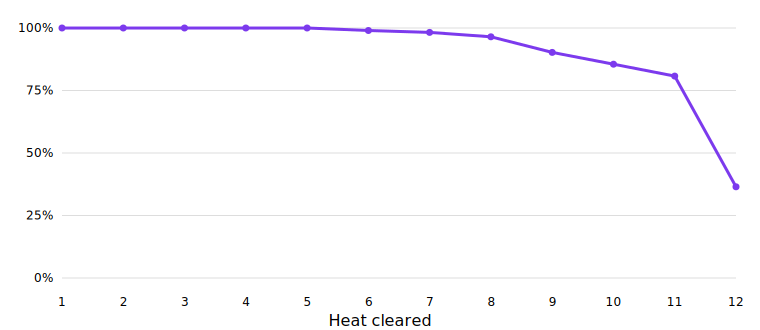

### Paired comparison against Flush engine

| Strategy | Delta | Approx. 95% CI | Strategy only | Leader only | Both win | Both lose |
| --- | --- | --- | --- | --- | --- | --- |
| Flush engine | +0.00 pp | +0.00 to +0.00 | 0 | 0 | 146 | 254 |
| Adaptive greedy | -7.25 pp | -13.36 to -1.14 | 64 | 93 | 53 | 190 |
| Utility and niche | -16.00 pp | -21.84 to -10.16 | 44 | 108 | 38 | 210 |
| Economy hoarding | -16.00 pp | -21.72 to -10.28 | 41 | 105 | 41 | 213 |
| Cheat + hand synergy | -25.00 pp | -30.12 to -19.88 | 17 | 117 | 29 | 237 |
| Pair and rank boosting | -28.50 pp | -33.73 to -23.27 | 16 | 130 | 16 | 238 |
| xMult stacking | -34.00 pp | -38.85 to -29.15 | 4 | 140 | 6 | 250 |

### Jokers in winning final builds

| Strategy | Wins | Most frequent final Jokers |
| --- | --- | --- |
| Flush engine | 146 | pocketflush (145/146), surge (78/146), uniform (63/146), presser (55/146), prism_lens (45/146) |
| Adaptive greedy | 117 | surge (83/117), butcher (49/117), redline (35/117), danger_music (32/117), polish (32/117) |
| Utility and niche | 82 | surge (55/82), butcher (30/82), shortcut (27/82), cleaner (27/82), sniper (24/82) |
| Economy hoarding | 82 | surge (52/82), piggy (30/82), butcher (28/82), danger_music (25/82), lastcall (24/82) |
| Cheat + hand synergy | 46 | cheat (46/46), surge (33/46), polish (18/46), trainer (14/46), practice_mode (14/46) |
| Pair and rank boosting | 32 | surge (22/32), butcher (13/32), even (12/32), trainer (11/32), triple3 (10/32) |
| xMult stacking | 10 | surge (7/10), redline (5/10), storm_harness (3/10), butcher (3/10), danger_music (3/10) |

### Revenue assumptions — sensitivity, not telemetry

| Scenario | Fill | Rewarded/day @ eCPM | Interstitial/day @ eCPM | MAU/DAU | Payer rate | ARPPU | Play fee |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Low | 75% | 1.0 @ £5.00 | 1.5 @ £1.50 | 2.0 | 0.30% | £3.00 | 30% |
| Base | 90% | 1.8 @ £10.00 | 2.5 @ £4.00 | 3.0 | 0.80% | £5.00 | 25% |
| High | 95% | 2.5 @ £15.00 | 3.5 @ £8.00 | 4.0 | 1.50% | £7.00 | 15% |

### Monthly sensitivity — not a forecast

**Current production ad revenue is £0.** Totals are before tax/refunds/chargebacks/FX.

| DAU | Low | Base | High |
| --- | --- | --- | --- |
| 50 | £8.79 | £42.30 | £111.19 |
| 200 | £35.14 | £169.20 | £444.75 |
| 1,000 | £175.73 | £846.00 | £2,223.75 |
| 10,000 | £1,757.25 | £8,460.00 | £22,237.50 |

### 1,000 DAU decomposition

| Scenario | Ads | IAP after assumed fee | Combined |
| --- | --- | --- | --- |
| Low | £163.13 | £12.60 | £175.73 |
| Base | £756.00 | £90.00 | £846.00 |
| High | £1,866.75 | £357.00 | £2,223.75 |

In [3]:
display(Markdown("### Strategy ranking\n\n"+table(
 ["Strategy","Heat 12","Win rate (Wilson 95% CI)","Reach H9","Reach H11","Avg cleared"],
 [(s["name"],f"{s['wins']}/{s['runs']}",
   f"{s['winRate']:.2f}% ({s['winRate95']['low']:.2f}–{s['winRate95']['high']:.2f}%)",
   f"{s['reachH9']:.2f}%",f"{s['reachH11']:.2f}%",f"{s['avgCleared']:.2f}") for s in ranked]
)))

flush=next(s for s in strategies if s["id"]=="flush_engine")
curve=[(heat,sum(o["cleared"]>=heat for o in flush["outcomes"])) for heat in range(1,13)]
display(Markdown("### Flush engine Heat-by-Heat clear curve\n\n"+table(
 ["Heat cleared","Runs","Share"],[(h,n,f"{100*n/N_RUNS:.2f}%") for h,n in curve]
)))
w,h,left,right,top,bottom=760,330,62,24,28,52
pw,ph=w-left-right,h-top-bottom
xp=lambda heat:left+(heat-1)*pw/11
yp=lambda pct:top+(100-pct)*ph/100
curve_pct=[(heat,100*n/N_RUNS) for heat,n in curve]
pts=" ".join(f"{xp(heat):.1f},{yp(pct):.1f}" for heat,pct in curve_pct)
grid="".join(
 f'<line x1="{left}" y1="{yp(p):.1f}" x2="{w-right}" y2="{yp(p):.1f}" stroke="#ddd"/>'
 f'<text x="{left-9}" y="{yp(p)+4:.1f}" text-anchor="end" font-size="12">{p}%</text>'
 for p in (0,25,50,75,100)
)
labels="".join(f'<text x="{xp(x):.1f}" y="{h-24}" text-anchor="middle" font-size="12">{x}</text>' for x in range(1,13))
dots="".join(f'<circle cx="{xp(x):.1f}" cy="{yp(y):.1f}" r="3.5" fill="#7c3aed"/>' for x,y in curve_pct)
svg=(f'<svg xmlns="http://www.w3.org/2000/svg" width="{w}" height="{h}"><rect width="100%" height="100%" fill="white"/>'
     +grid+f'<polyline points="{pts}" fill="none" stroke="#7c3aed" stroke-width="3"/>'+dots+labels+
     f'<text x="{w/2}" y="{h-4}" text-anchor="middle">Heat cleared</text></svg>')
display(SVG(svg))

paired_rows=[]
for s in ranked:
    d,lo,hi=paired_gap(s,leader)
    raw=next(r for r in paired if r["id"]==s["id"])
    paired_rows.append((s["name"],f"{d:+.2f} pp",f"{lo:+.2f} to {hi:+.2f}",
                        raw["strategyOnly"],raw["bestOnly"],raw["bothWin"],raw["bothLose"]))
display(Markdown("### Paired comparison against "+leader["name"]+"\n\n"+table(
 ["Strategy","Delta","Approx. 95% CI","Strategy only","Leader only","Both win","Both lose"],paired_rows
)))

joker_rows=[]
for s in ranked:
    wins=[o for o in s["outcomes"] if o["won"]]
    counts=Counter(j for o in wins for j in set(o.get("finalJokers",[])))
    top=", ".join(f"{j} ({n}/{len(wins)})" for j,n in counts.most_common(5)) or "No wins"
    joker_rows.append((s["name"],len(wins),top))
display(Markdown("### Jokers in winning final builds\n\n"+table(
 ["Strategy","Wins","Most frequent final Jokers"],joker_rows
)))

assumption_rows=[(
 s["label"],f"{100*s['fillRate']:.0f}%",
 f"{s['rewardedViewsPerDauDay']:.1f} @ £{s['rewardedEcpmGbp']:.2f}",
 f"{s['interstitialViewsPerDauDay']:.1f} @ £{s['interstitialEcpmGbp']:.2f}",
 f"{s['mauPerDau']:.1f}",f"{100*s['monthlyPayerRate']:.2f}%",
 f"£{s['grossMonthlyArppuGbp']:.2f}",f"{100*s['playFeeRate']:.0f}%"
) for s in revenue["scenarios"]]
display(Markdown("### Revenue assumptions — sensitivity, not telemetry\n\n"+table(
 ["Scenario","Fill","Rewarded/day @ eCPM","Interstitial/day @ eCPM","MAU/DAU","Payer rate","ARPPU","Play fee"],
 assumption_rows
)))
sensitivity=[(f"{dau:,}",*[
 f"£{projections[(scenario,dau)]['monthlyTotalBeforeTaxRefundsGbp']:,.2f}"
 for scenario in ("low","base","high")]) for dau in DAU_LEVELS]
display(Markdown(
 "### Monthly sensitivity — not a forecast\n\n"
 "**Current production ad revenue is £0.** Totals are before tax/refunds/chargebacks/FX.\n\n"+
 table(["DAU","Low","Base","High"],sensitivity)
))
display(Markdown("### 1,000 DAU decomposition\n\n"+table(
 ["Scenario","Ads","IAP after assumed fee","Combined"],
 [(scenarios[s]["label"],f"£{projections[(s,1000)]['monthlyAdsGbp']:,.2f}",
   f"£{projections[(s,1000)]['monthlyIapAfterPlayFeeGbp']:,.2f}",
   f"£{projections[(s,1000)]['monthlyTotalBeforeTaxRefundsGbp']:,.2f}")
  for s in ("low","base","high")]
)))

## Takeaways

These conclusions retain the limitations of bot heuristics and assumption-driven revenue sensitivities.

In [4]:
resolved=gap_low>0 or gap_high<0
display(Markdown(
 f"1. **Share with caveats:** every provenance, completeness, grain, and arithmetic check passed.\n"
 f"2. **{leader['name']} is the strongest tested heuristic** at {leader['winRate']:.2f}%, "
 f"ahead of {runner_up['name']} at {runner_up['winRate']:.2f}%. "
 +("The paired interval excludes zero." if resolved else "The paired interval includes zero; the ordering is unresolved.")+
 f"\n3. **{ranked[-1]['name']} is weakest at {ranked[-1]['winRate']:.2f}%**, a balance diagnostic—not proof about player potential.\n"
 f"4. **Revenue is not forecastable from these files.** Current demo/test ads earn £0, Play activation is unverified, "
 f"and every projected value depends on explicit assumptions.\n"
 f"5. Preserve these hashes, rerun after gameplay changes, and replace assumptions with internal-test telemetry."
))

1. **Share with caveats:** every provenance, completeness, grain, and arithmetic check passed.
2. **Flush engine is the strongest tested heuristic** at 36.50%, ahead of Adaptive greedy at 29.25%. The paired interval excludes zero.
3. **xMult stacking is weakest at 2.50%**, a balance diagnostic—not proof about player potential.
4. **Revenue is not forecastable from these files.** Current demo/test ads earn £0, Play activation is unverified, and every projected value depends on explicit assumptions.
5. Preserve these hashes, rerun after gameplay changes, and replace assumptions with internal-test telemetry.